In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np

# Ultralytics
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd()
TEST_IMAGES_DIR = PROJECT_ROOT / "BARS_yolo" / "images" / "test"
WEIGHTS = PROJECT_ROOT / "epoch70.pt"

assert TEST_IMAGES_DIR.exists(), f"Missing: {TEST_IMAGES_DIR}"
assert WEIGHTS.exists(), f"Missing: {WEIGHTS}"


In [3]:
# Pick a few random images from the test set
IMG_EXTS = {".jpg", ".jpeg", ".png"}
all_imgs = sorted([p for p in TEST_IMAGES_DIR.iterdir() if p.suffix.lower() in IMG_EXTS])

N_SAMPLES = 6
random.seed(0)
sample_paths = random.sample(all_imgs, k=min(N_SAMPLES, len(all_imgs)))

len(all_imgs), [p.name for p in sample_paths]


(1250,
 ['XPlane5_516.jpg',
  'XPlane_6082.jpg',
  'DAAG_27.jpg',
  'VTBS_21.jpg',
  'XPlane_ZSNB_591.jpg',
  'XPlane_ZGSZ_242.jpg'])

WARNING ⚠️ NMS time limit 2.050s exceeded


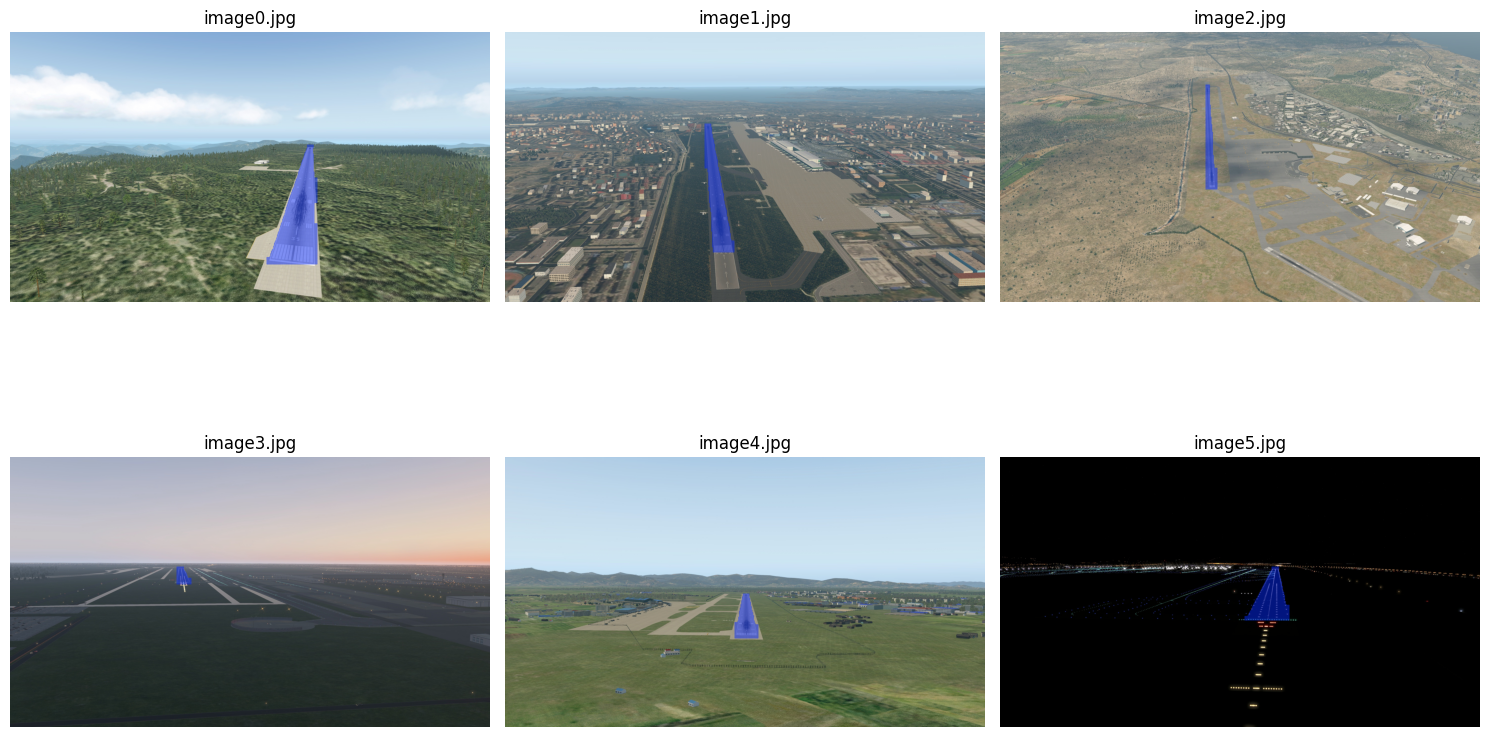

In [4]:
# Run segmentation inference and plot overlays
model = YOLO(str(WEIGHTS))

results = model.predict(
    source=[str(p) for p in sample_paths],
    imgsz=640,
    conf=0.25,
    device="mps",  # change to "cpu" if needed
    verbose=False,
)

n = len(results)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, res in zip(axes, results):
    # Ultralytics returns BGR image from .plot()
    vis_bgr = res.plot(boxes=False)
    vis_rgb = vis_bgr[..., ::-1]
    ax.imshow(vis_rgb)
    ax.set_title(Path(res.path).name)
    ax.axis("off")

for ax in axes[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


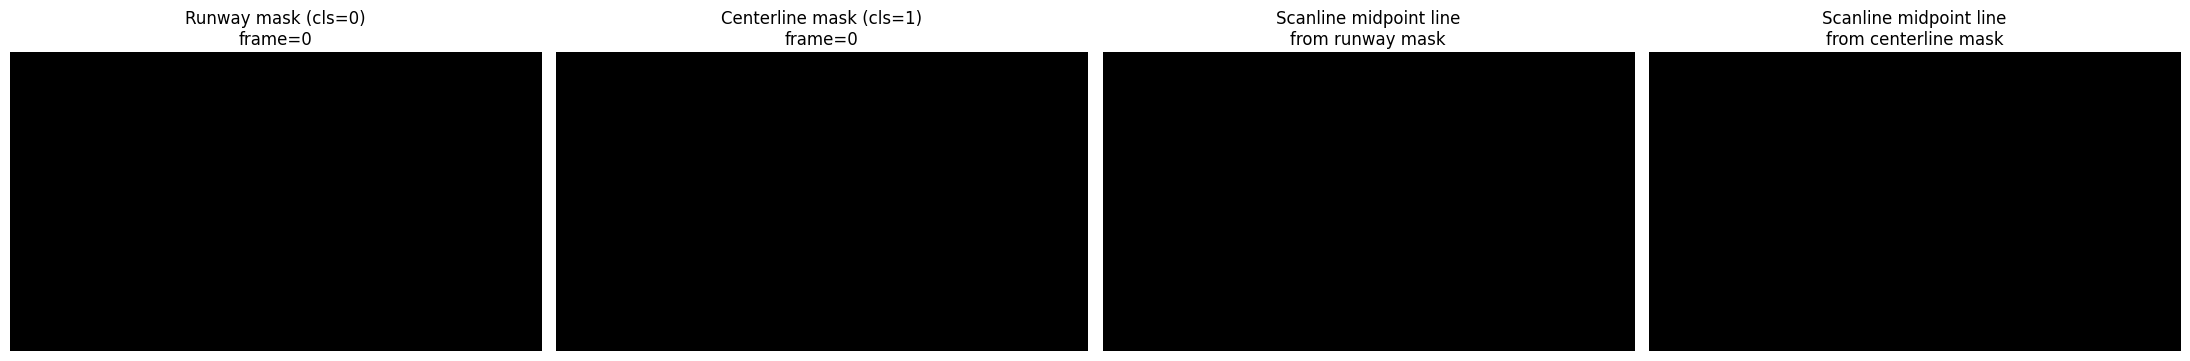

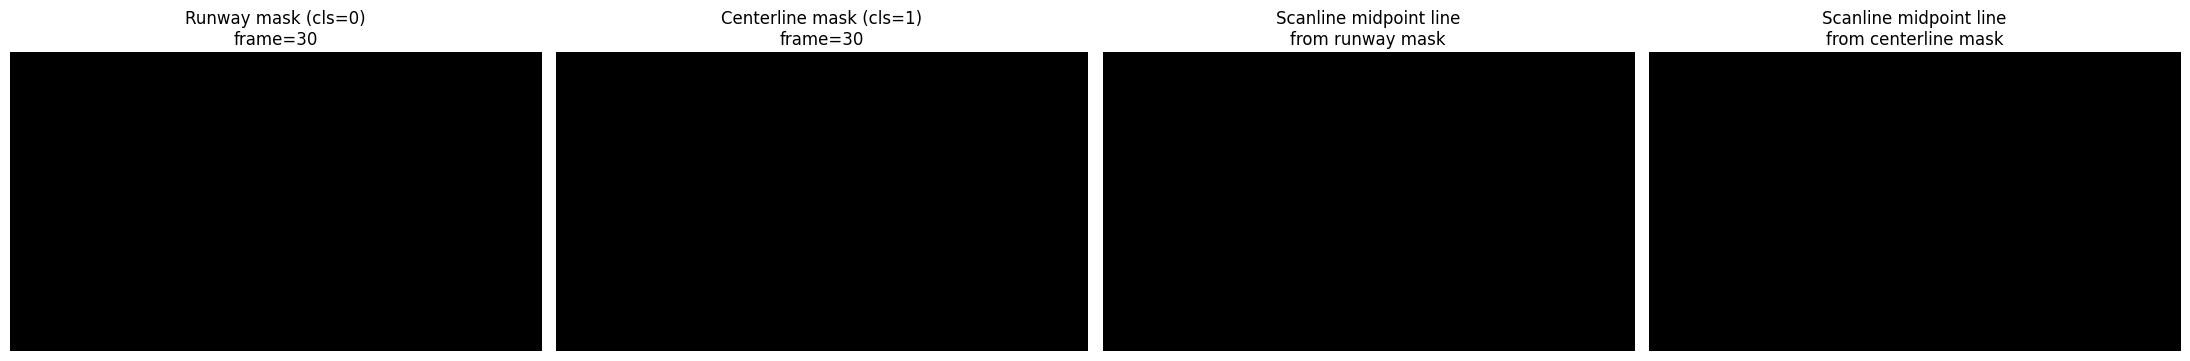

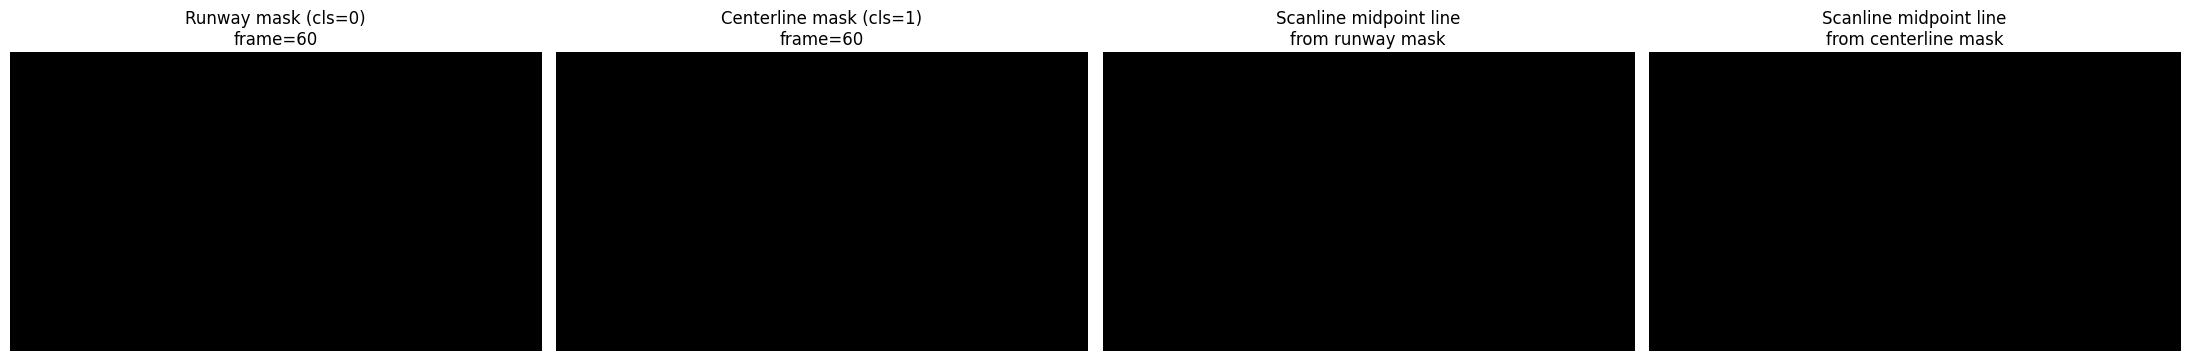

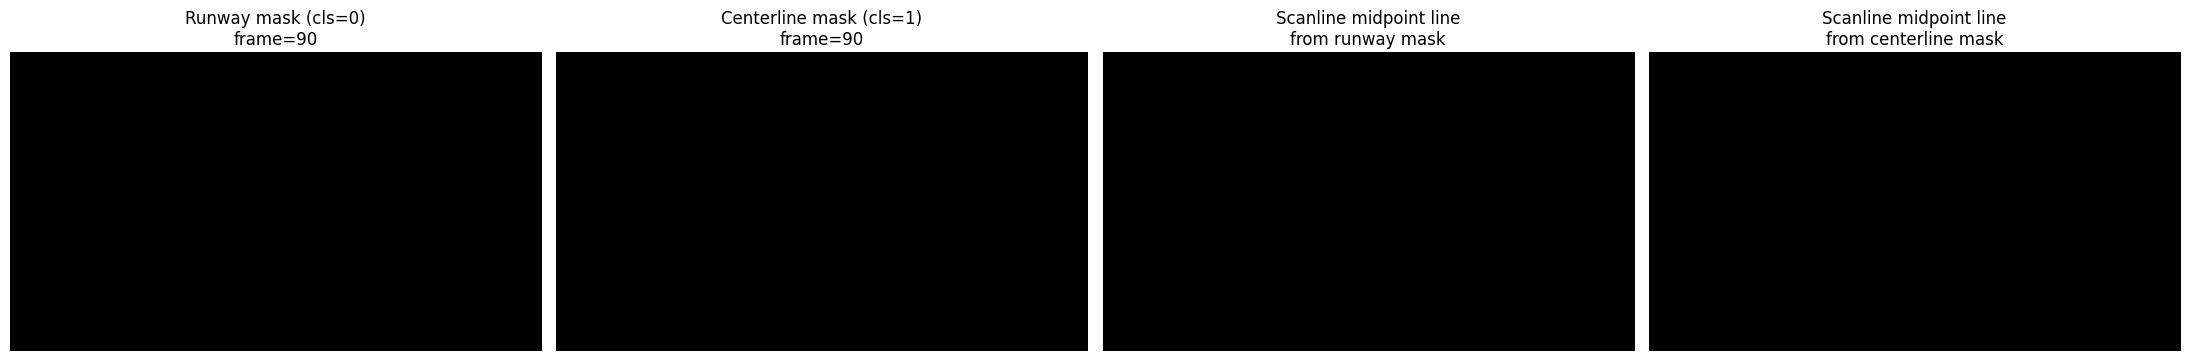

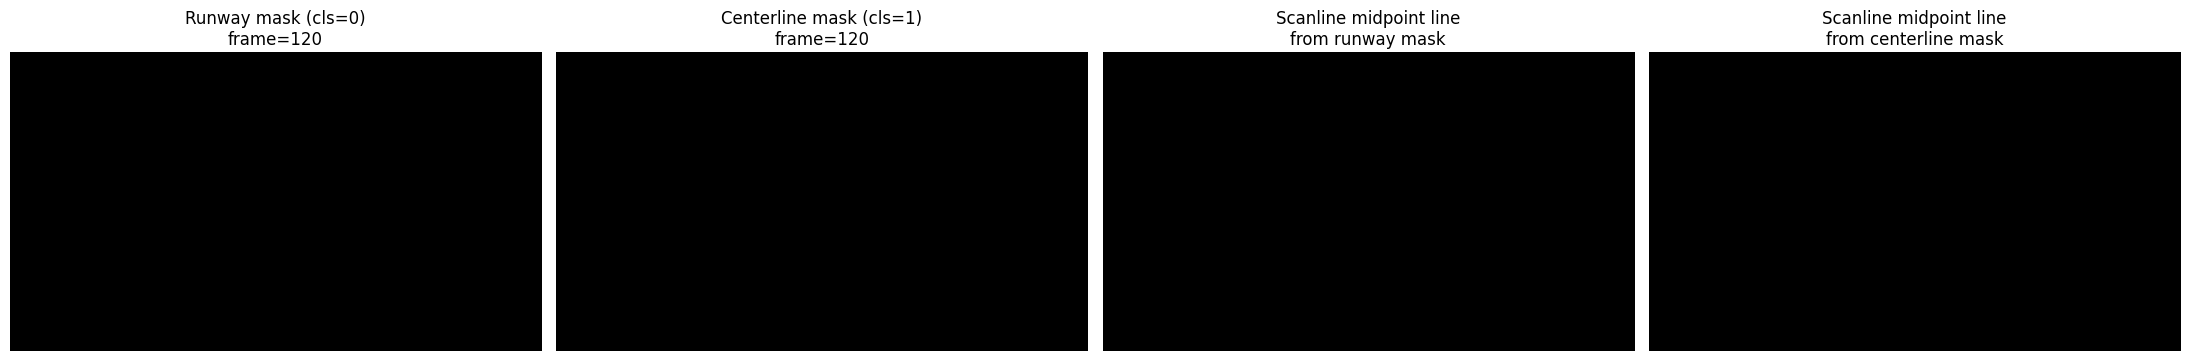

Done. Shown 5 frames.


In [ ]:
# Video inference + visualization (runway mask, centerline mask, scanline-midpoint lines)
import cv2

VIDEO_PATH = PROJECT_ROOT / "videos" / "HPA_LA_720p_10hz.mp4"
WEIGHTS = PROJECT_ROOT / "epoch.pt"  # ensure using the centerline+runway model

assert VIDEO_PATH.exists(), f"Missing: {VIDEO_PATH}"
assert WEIGHTS.exists(), f"Missing: {WEIGHTS}"

# Class ids in the segmentation model (adjust if needed)
RUNWAY_CLS = 0
CENTERLINE_CLS = 1

# Controls
N_FRAMES_TO_SHOW = 5
FRAME_STRIDE = 30       # show every Nth frame
SCANLINE_STEP = 5       # take a scanline every N pixels
IMGSZ = 640
CONF = 0.25
DEVICE = "mps"  # change to "cpu" if needed

model = YOLO(str(WEIGHTS))


def union_mask_for_class(result, cls_id: int, orig_shape: tuple[int, int]) -> np.ndarray | None:
    """Return (H,W) uint8 mask {0,255} for a given class id, resized to orig_shape."""
    if result.masks is None or result.masks.data is None or len(result.masks.data) == 0:
        return None

    m = result.masks.data  # (N, h, w)
    # Ultralytics stores classes in boxes.cls aligned with masks
    if result.boxes is None or result.boxes.cls is None:
        return None
    cls = result.boxes.cls

    if isinstance(cls, torch.Tensor):
        cls_np = cls.detach().cpu().numpy().astype(int)
    else:
        cls_np = np.asarray(cls, dtype=int)

    if isinstance(m, torch.Tensor):
        m_np = m.detach().cpu().numpy()
    else:
        m_np = np.asarray(m)

    idxs = np.where(cls_np == int(cls_id))[0]
    if idxs.size == 0:
        return None

    union = np.max((m_np[idxs] > 0.5).astype(np.float32), axis=0)  # (h, w)
    H, W = orig_shape
    resized = cv2.resize(union, (W, H), interpolation=cv2.INTER_LINEAR)
    return ((resized > 0.5).astype(np.uint8) * 255)


def scanline_midpoints(mask_bin: np.ndarray, step: int = 5) -> list[tuple[float, float]]:
    """For each y scanline, take midpoint between first & last positive pixel."""
    H, W = mask_bin.shape
    pts: list[tuple[float, float]] = []
    for y in range(0, H, step):
        xs = np.where(mask_bin[y, :] > 0)[0]
        if xs.size < 2:
            continue
        x_center = 0.5 * (float(xs[0]) + float(xs[-1]))
        pts.append((x_center, float(y)))
    return pts


def fit_line_from_points(points: list[tuple[float, float]], H: int, W: int):
    """Fit a line with cv2.fitLine and return endpoints (p1,p2) in image coords."""
    if len(points) < 2:
        return None
    pts = np.array(points, dtype=np.float32)
    vx, vy, x0, y0 = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    vx, vy, x0, y0 = [float(v.squeeze()) for v in (vx, vy, x0, y0)]
    if abs(vy) < 1e-6:
        return None
    t_top = -y0 / vy
    t_bottom = (H - 1 - y0) / vy
    x_top = x0 + t_top * vx
    x_bottom = x0 + t_bottom * vx
    p1 = (int(np.clip(x_top, 0, W - 1)), 0)
    p2 = (int(np.clip(x_bottom, 0, W - 1)), H - 1)
    return p1, p2


def render_line_mask(H: int, W: int, p1, p2, thickness: int = 3) -> np.ndarray:
    out = np.zeros((H, W), dtype=np.uint8)
    if p1 is None or p2 is None:
        return out
    cv2.line(out, p1, p2, 255, thickness)
    return out


cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open: {VIDEO_PATH}")

shown = 0
frame_idx = -1

while shown < N_FRAMES_TO_SHOW:
    ok, frame_bgr = cap.read()
    if not ok:
        break
    frame_idx += 1
    if frame_idx % FRAME_STRIDE != 0:
        continue

    res = model.predict(source=frame_bgr, conf=CONF, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
    H, W = frame_bgr.shape[:2]

    runway_mask = union_mask_for_class(res, RUNWAY_CLS, (H, W))
    centerline_mask = union_mask_for_class(res, CENTERLINE_CLS, (H, W))

    runway_bin = (runway_mask > 0).astype(np.uint8) if runway_mask is not None else np.zeros((H, W), np.uint8)
    centerline_bin = (centerline_mask > 0).astype(np.uint8) if centerline_mask is not None else np.zeros((H, W), np.uint8)

    # Scanline midpoint lines
    runway_pts = scanline_midpoints(runway_bin, step=SCANLINE_STEP)
    cen_pts = scanline_midpoints(centerline_bin, step=SCANLINE_STEP)

    runway_line = fit_line_from_points(runway_pts, H, W)
    cen_line = fit_line_from_points(cen_pts, H, W)

    runway_line_mask = render_line_mask(H, W, *(runway_line or (None, None)))
    cen_line_mask = render_line_mask(H, W, *(cen_line or (None, None)))

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(runway_bin * 255, cmap="gray")
    axes[0].set_title(f"Runway mask (cls={RUNWAY_CLS})\nframe={frame_idx}")
    axes[0].axis("off")

    axes[1].imshow(centerline_bin * 255, cmap="gray")
    axes[1].set_title(f"Centerline mask (cls={CENTERLINE_CLS})\nframe={frame_idx}")
    axes[1].axis("off")

    axes[2].imshow(runway_line_mask, cmap="gray")
    axes[2].set_title("Scanline midpoint line\nfrom runway mask")
    axes[2].axis("off")

    axes[3].imshow(cen_line_mask, cmap="gray")
    axes[3].set_title("Scanline midpoint line\nfrom centerline mask")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    shown += 1

cap.release()
print(f"Done. Shown {shown} frames.")


In [2]:
import numpy as np

In [6]:
def union_mask_for_class(result, cls_id: int, orig_shape: tuple[int, int]) -> np.ndarray | None:
    """Return (H,W) uint8 mask {0,255} for a given class id, resized to orig_shape."""
    if result.masks is None or result.masks.data is None or len(result.masks.data) == 0:
        return None
    if result.boxes is None or result.boxes.cls is None:
        return None

    m = result.masks.data
    cls = result.boxes.cls

    if isinstance(cls, torch.Tensor):
        cls_np = cls.detach().cpu().numpy().astype(int)
    else:
        cls_np = np.asarray(cls, dtype=int)

    if isinstance(m, torch.Tensor):
        m_np = m.detach().cpu().numpy()
    else:
        m_np = np.asarray(m)

    idxs = np.where(cls_np == int(cls_id))[0]
    if idxs.size == 0:
        return None

    union = np.max((m_np[idxs] > 0.5).astype(np.float32), axis=0)
    H, W = orig_shape
    resized = cv2.resize(union, (W, H), interpolation=cv2.INTER_LINEAR)
    return ((resized > 0.5).astype(np.uint8) * 255)


def scanline_midpoints(mask_dt: np.ndarray, step: int) -> list[tuple[float, float]]:
    """mask_dt is {0,1}. For each y, midpoint between first & last positive pixel."""
    H, W = mask_dt.shape
    pts: list[tuple[float, float]] = []
    for y in range(0, H, step):
        xs = np.where(mask_dt[y, :] > 0)[0]
        if xs.size < 2:
            continue
        x_center = 0.5 * (float(xs[0]) + float(xs[-1]))
        pts.append((x_center, float(y)))
    return pts


def fit_line_endpoints(points: list[tuple[float, float]], H: int, W: int):
    if len(points) < 2:
        return None
    pts = np.array(points, dtype=np.float32)
    vx, vy, x0, y0 = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    vx, vy, x0, y0 = [float(v.squeeze()) for v in (vx, vy, x0, y0)]
    if abs(vy) < 1e-3:
        return None
    t_top = -y0 / vy
    t_bottom = (H - 1 - y0) / vy
    x_top = x0 + t_top * vx
    x_bottom = x0 + t_bottom * vx
    p1 = (int(np.clip(x_top, 0, W - 1)), 0)
    p2 = (int(np.clip(x_bottom, 0, W - 1)), H - 1)
    return p1, p2

In [7]:
import torch

In [13]:
from ultralytics import YOLO
from pathlib import Path

VIDEO_PATH = PROJECT_ROOT / "videos" / "HPA_LA_720p_10hz.mp4"

model = YOLO("epoch70.pt")  # ou ton modèle custom de seg

results= model.track(
    source=str(VIDEO_PATH),
    save=True,           # sauve la vidéo annotée
    show=True,           # affiche en “temps réel” dans une fenêtre
    stream=True,
    conf=0.25,
    imgsz=640,
    tracker="bytetrack.yaml",  # ou BOTSORT, etc.
)
for r in results:
    # ici r contient les résultats pour une ou plusieurs frames
    # tu pourrais ajouter ton propre traitement si besoin
    pass


video 1/1 (frame 1/1200) /Users/samuelmoyal/Documents/Documents - MacBook Air de Samuel/Carnegie Mellon /cours/Capstone/Codebase2/videos/HPA_LA_720p_10hz.mp4: 384x640 (no detections), 97.9ms
video 1/1 (frame 2/1200) /Users/samuelmoyal/Documents/Documents - MacBook Air de Samuel/Carnegie Mellon /cours/Capstone/Codebase2/videos/HPA_LA_720p_10hz.mp4: 384x640 (no detections), 74.9ms
video 1/1 (frame 3/1200) /Users/samuelmoyal/Documents/Documents - MacBook Air de Samuel/Carnegie Mellon /cours/Capstone/Codebase2/videos/HPA_LA_720p_10hz.mp4: 384x640 (no detections), 72.3ms
video 1/1 (frame 4/1200) /Users/samuelmoyal/Documents/Documents - MacBook Air de Samuel/Carnegie Mellon /cours/Capstone/Codebase2/videos/HPA_LA_720p_10hz.mp4: 384x640 (no detections), 69.5ms
video 1/1 (frame 5/1200) /Users/samuelmoyal/Documents/Documents - MacBook Air de Samuel/Carnegie Mellon /cours/Capstone/Codebase2/videos/HPA_LA_720p_10hz.mp4: 384x640 (no detections), 69.0ms
video 1/1 (frame 6/1200) /Users/samuelmoyal/

In [1]:

def scanline_midpoints(mask_dt: np.ndarray, step: int) -> list[tuple[float, float]]:
    """mask_dt is {0,1}. For each y, midpoint between first & last positive pixel."""
    H, W = mask_dt.shape
    pts: list[tuple[float, float]] = []
    for y in range(0, H, step):
        xs = np.where(mask_dt[y, :] > 0)[0]
        if xs.size < 2:
            continue
        x_center = 0.5 * (float(xs[0]) + float(xs[-1]))
        pts.append((x_center, float(y)))
    return pts


def fit_line_endpoints(points: list[tuple[float, float]], H: int, W: int):
    if len(points) < 2:
        return None
    pts = np.array(points, dtype=np.float32)
    vx, vy, x0, y0 = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    vx, vy, x0, y0 = [float(v.squeeze()) for v in (vx, vy, x0, y0)]
    if abs(vy) < 1e-3:
        return None
    t_top = -y0 / vy
    t_bottom = (H - 1 - y0) / vy
    x_top = x0 + t_top * vx
    x_bottom = x0 + t_bottom * vx
    p1 = (int(np.clip(x_top, 0, W - 1)), 0)
    p2 = (int(np.clip(x_bottom, 0, W - 1)), H - 1)
    return p1, p2

NameError: name 'np' is not defined

In [8]:
import torch

In [ ]:
# Video inference -> write an output video with overlays + 2 scanline midpoint lines
import cv2

INPUT_VIDEO = PROJECT_ROOT / "videos" / "HPA_LA_720p_10hz.mp4"
OUTPUT_VIDEO = PROJECT_ROOT / "runs" / "segment" / "one_stage" / "HPA_LA_720p_10hz_runway_centerline_scanline.mp4"
OUTPUT_VIDEO.parent.mkdir(parents=True, exist_ok=True)

# Ensure the right model
WEIGHTS = PROJECT_ROOT / "valnet_epoch80.pt"
model = YOLO(str(WEIGHTS))

# Class ids (adjust if needed)
RUNWAY_CLS = 0
CENTERLINE_CLS = 1

CONF = 0.25
IMGSZ = 640
DEVICE = "mps"  # change to "cpu" if needed
SCANLINE_STEP = 5

# Morphological cleanup (like your two-stage cell)
kernel = np.ones((7, 7), np.uint8)


cap = cv2.VideoCapture(str(INPUT_VIDEO))
if not cap.isOpened():
    raise FileNotFoundError(f"Vidéo introuvable: {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS) or 10.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, fps, (w, h))

frame_idx = 0
while True:
    ok, frame_bgr = cap.read()
    if not ok:
        break

    res = model.predict(source=frame_bgr, conf=CONF, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]

    runway_mask = union_mask_for_class(res, RUNWAY_CLS, (h, w))
    centerline_mask = union_mask_for_class(res, CENTERLINE_CLS, (h, w))

    # Clean up masks
    runway_dt = np.zeros((h, w), dtype=np.uint8)
    centerline_dt = np.zeros((h, w), dtype=np.uint8)

    if runway_mask is not None and np.any(runway_mask > 0):
        runway_bin = (runway_mask > 0).astype(np.uint8) * 255
        runway_refined = cv2.morphologyEx(runway_bin, cv2.MORPH_CLOSE, kernel)
        runway_dt = (runway_refined > 0).astype(np.uint8)

    if centerline_mask is not None and np.any(centerline_mask > 0):
        cl_bin = (centerline_mask > 0).astype(np.uint8) * 255
        cl_refined = cv2.morphologyEx(cl_bin, cv2.MORPH_CLOSE, kernel)
        centerline_dt = (cl_refined > 0).astype(np.uint8)

    # Scanline midpoint lines
    runway_pts = scanline_midpoints(runway_dt, step=SCANLINE_STEP)
    cl_pts = scanline_midpoints(centerline_dt, step=SCANLINE_STEP)

    runway_line = fit_line_endpoints(runway_pts, h, w)
    cl_line = fit_line_endpoints(cl_pts, h, w)

    # Draw lines on frame
    if runway_line is not None:
        cv2.line(frame_bgr, runway_line[0], runway_line[1], (0, 255, 0), 3)      # green
    if cl_line is not None:
        cv2.line(frame_bgr, cl_line[0], cl_line[1], (255, 0, 255), 3)           # magenta

    # Overlay masks (semi-transparent)
    overlay = frame_bgr.copy()
    if runway_dt.any():
        overlay[runway_dt > 0] = (0, 128, 255)      # orange
    if centerline_dt.any():
        overlay[centerline_dt > 0] = (255, 255, 0)  # cyan/yellow-ish
    cv2.addWeighted(overlay, 0.35, frame_bgr, 0.65, 0, frame_bgr)

    out.write(frame_bgr)
    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"Frames traitées: {frame_idx}")

cap.release()
out.release()
print(f"Vidéo créée: {OUTPUT_VIDEO}")


Frames traitées: 50
Frames traitées: 100
Frames traitées: 150
Frames traitées: 200
Frames traitées: 250
Frames traitées: 300
Frames traitées: 350
Frames traitées: 400
Frames traitées: 450
Frames traitées: 500
Frames traitées: 550
Frames traitées: 600
Frames traitées: 650
Frames traitées: 700
Frames traitées: 750
Frames traitées: 800
Frames traitées: 850
Frames traitées: 900
Frames traitées: 950
Frames traitées: 1000
Frames traitées: 1050
Frames traitées: 1100
Frames traitées: 1150
Frames traitées: 1200
Vidéo créée: /Users/samuelmoyal/iCloud Drive (archives)/Documents/Documents - MacBook Air de Samuel/Carnegie Mellon /cours/Capstone/Codebase2/runs/segment/one_stage/HPA_LA_720p_10hz_runway_centerline_scanline.mp4


In [11]:
# Video inference -> write an output video with overlays + 2 scanline midpoint lines
import cv2

INPUT_VIDEO = PROJECT_ROOT / "videos" / "HPA_LA_720p_10hz.mp4"
OUTPUT_VIDEO = PROJECT_ROOT / "runs" / "segment" / "valnet" / "HPA_LA_720p_10hz_runway_centerline_scanline.mp4"
OUTPUT_VIDEO.parent.mkdir(parents=True, exist_ok=True)

# Ensure the right model
WEIGHTS = PROJECT_ROOT / "valnet_epoch80.pt"
if "model" not in globals() or model is None:
    model = YOLO(str(WEIGHTS))

# Class ids (adjust if needed)
RUNWAY_CLS = 0
CENTERLINE_CLS = 1

CONF = 0.25
IMGSZ = 640
DEVICE = "mps"  # change to "cpu" if needed
SCANLINE_STEP = 5

# Morphological cleanup (like your two-stage cell)
kernel = np.ones((7, 7), np.uint8)


cap = cv2.VideoCapture(str(INPUT_VIDEO))
if not cap.isOpened():
    raise FileNotFoundError(f"Vidéo introuvable: {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS) or 10.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, fps, (w, h))

frame_idx = 0
while True:
    ok, frame_bgr = cap.read()
    if not ok:
        break

    res = model.predict(source=frame_bgr, conf=CONF, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]

    runway_mask = union_mask_for_class(res, RUNWAY_CLS, (h, w))
    '''
    centerline_mask = union_mask_for_class(res, CENTERLINE_CLS, (h, w))

    # Clean up masks
    runway_dt = np.zeros((h, w), dtype=np.uint8)
    centerline_dt = np.zeros((h, w), dtype=np.uint8)

    if runway_mask is not None and np.any(runway_mask > 0):
        runway_bin = (runway_mask > 0).astype(np.uint8) * 255
        runway_refined = cv2.morphologyEx(runway_bin, cv2.MORPH_CLOSE, kernel)
        runway_dt = (runway_refined > 0).astype(np.uint8)

    if centerline_mask is not None and np.any(centerline_mask > 0):
        cl_bin = (centerline_mask > 0).astype(np.uint8) * 255
        cl_refined = cv2.morphologyEx(cl_bin, cv2.MORPH_CLOSE, kernel)
        centerline_dt = (cl_refined > 0).astype(np.uint8)

    # Scanline midpoint lines
    runway_pts = scanline_midpoints(runway_dt, step=SCANLINE_STEP)
    cl_pts = scanline_midpoints(centerline_dt, step=SCANLINE_STEP)

    runway_line = fit_line_endpoints(runway_pts, h, w)
    cl_line = fit_line_endpoints(cl_pts, h, w)
    

    # Draw lines on frame
    if runway_line is not None:
        cv2.line(frame_bgr, runway_line[0], runway_line[1], (0, 255, 0), 3)      # green
    if cl_line is not None:
        cv2.line(frame_bgr, cl_line[0], cl_line[1], (255, 0, 255), 3)           # magenta

    '''
    # Overlay masks (semi-transparent)
    overlay = frame_bgr.copy()
    if runway_dt.any():
        overlay[runway_dt > 0] = (0, 128, 255)      # orange
    if centerline_dt.any():
        overlay[centerline_dt > 0] = (255, 255, 0)  # cyan/yellow-ish
    cv2.addWeighted(overlay, 0.35, frame_bgr, 0.65, 0, frame_bgr)


    out.write(frame_bgr)
    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"Frames traitées: {frame_idx}")

cap.release()
out.release()
print(f"Vidéo créée: {OUTPUT_VIDEO}")

Frames traitées: 50
Frames traitées: 100
Frames traitées: 150
Frames traitées: 200
Frames traitées: 250
Frames traitées: 300
Frames traitées: 350
Frames traitées: 400
Frames traitées: 450
Frames traitées: 500
Frames traitées: 550
Frames traitées: 600
Frames traitées: 650
Frames traitées: 700
Frames traitées: 750
Frames traitées: 800
Frames traitées: 850
Frames traitées: 900
Frames traitées: 950
Frames traitées: 1000
Frames traitées: 1050
Frames traitées: 1100
Frames traitées: 1150
Frames traitées: 1200
Vidéo créée: /Users/samuelmoyal/iCloud Drive (archives)/Documents/Documents - MacBook Air de Samuel/Carnegie Mellon /cours/Capstone/Codebase2/runs/segment/valnet/HPA_LA_720p_10hz_runway_centerline_scanline.mp4


In [12]:

def angle_between_segments(mid_top_a, mid_bottom_a, mid_top_b, mid_bottom_b):
    """Angle en degrés entre les directions des deux segments (0 = parallèles)."""
    da = np.asarray(mid_bottom_a) - np.asarray(mid_top_a)
    db = np.asarray(mid_bottom_b) - np.asarray(mid_top_b)
    na = np.linalg.norm(da)
    nb = np.linalg.norm(db)
    if na < 1e-9 or nb < 1e-9:
        return float("nan")
    cos_angle = np.clip(np.dot(da, db) / (na * nb), -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))


def point_to_line_distance(p, line_start, line_end):
    """Distance perpendiculaire du point p à la droite (line_start, line_end)."""
    p = np.asarray(p, dtype=np.float64)
    a = np.asarray(line_start, dtype=np.float64)
    b = np.asarray(line_end, dtype=np.float64)
    ab = b - a
    n = np.linalg.norm(ab)
    if n < 1e-9:
        return np.linalg.norm(p - a)
    return np.abs(np.cross(ab, p - a)) / n


def center_line_offset_error(mid_top_ref, mid_bottom_ref, mid_top_test, mid_bottom_test):
    """Offset en pixels : distance du milieu de la ligne test à la ligne ref."""
    mid_test = (np.asarray(mid_top_test) + np.asarray(mid_bottom_test)) / 2
    return point_to_line_distance(mid_test, mid_top_ref, mid_bottom_ref)

In [17]:
# Evaluate angle/offset on validation set: GT line vs predicted line (pred mask + postprocessing)
import cv2
import numpy as np
from pathlib import Path

# Optional pretty table
try:
    import pandas as pd
except Exception:
    pd = None

# Paths
VAL_LABEL_DIR = PROJECT_ROOT / "BARS_yolo" / "labels_c_r" / "val"
VAL_IMG_DIR = PROJECT_ROOT / "BARS_yolo" / "images" / "val"
WEIGHTS = PROJECT_ROOT / "valnet_epoch80.pt"

assert VAL_LABEL_DIR.exists(), f"Missing: {VAL_LABEL_DIR}"
assert VAL_IMG_DIR.exists(), f"Missing: {VAL_IMG_DIR}"
assert WEIGHTS.exists(), f"Missing: {WEIGHTS}"

# Class IDs (adjust if your dataset uses different mapping)
GT_LINE_CLS = 0          # line class in labels_c_r (often centerline)
PRED_MASK_CLS = 0        # predicted class used to build the line mask

CONF = 0.25
IMGSZ = 640
DEVICE = "mps"          # change to "cpu" if needed
SCANLINE_STEP = 5
KERNEL = np.ones((7, 7), np.uint8)
MAX_SAMPLES = None       # e.g. 200 for quick run

model = YOLO(str(WEIGHTS))

# Fallbacks (if previous helper cells were not run)
if "angle_between_segments" not in globals():
    def angle_between_segments(mid_top_a, mid_bottom_a, mid_top_b, mid_bottom_b):
        da = np.asarray(mid_bottom_a) - np.asarray(mid_top_a)
        db = np.asarray(mid_bottom_b) - np.asarray(mid_top_b)
        na = np.linalg.norm(da)
        nb = np.linalg.norm(db)
        if na < 1e-9 or nb < 1e-9:
            return float("nan")
        cos_angle = np.clip(np.dot(da, db) / (na * nb), -1.0, 1.0)
        return np.degrees(np.arccos(cos_angle))

if "point_to_line_distance" not in globals():
    def point_to_line_distance(p, line_start, line_end):
        p = np.asarray(p, dtype=np.float64)
        a = np.asarray(line_start, dtype=np.float64)
        b = np.asarray(line_end, dtype=np.float64)
        ab = b - a
        n = np.linalg.norm(ab)
        if n < 1e-9:
            return np.linalg.norm(p - a)
        return np.abs(np.cross(ab, p - a)) / n

if "center_line_offset_error" not in globals():
    def center_line_offset_error(mid_top_ref, mid_bottom_ref, mid_top_test, mid_bottom_test):
        mid_test = (np.asarray(mid_top_test) + np.asarray(mid_bottom_test)) / 2
        return point_to_line_distance(mid_test, mid_top_ref, mid_bottom_ref)


def load_class_mask_from_yolo_seg(txt_path: Path, h: int, w: int, cls_id: int) -> np.ndarray:
    """Build binary mask {0,1} for one class from a YOLO-seg txt file."""
    mask = np.zeros((h, w), dtype=np.uint8)
    if not txt_path.exists():
        return mask

    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            try:
                c = int(float(parts[0]))
            except Exception:
                continue
            if c != int(cls_id):
                continue

            coords = np.array(parts[1:], dtype=np.float32)
            if coords.size % 2 != 0:
                continue
            pts = coords.reshape(-1, 2)
            pts_px = np.zeros_like(pts)
            pts_px[:, 0] = np.clip(pts[:, 0] * w, 0, w - 1)
            pts_px[:, 1] = np.clip(pts[:, 1] * h, 0, h - 1)
            cv2.fillPoly(mask, [pts_px.astype(np.int32)], 1)

    return mask


def pred_union_mask_for_class(result, cls_id: int, h: int, w: int) -> np.ndarray | None:
    """Build class-specific predicted union mask {0,255} resized to (h,w)."""
    if result.masks is None or result.masks.data is None or len(result.masks.data) == 0:
        return None
    if result.boxes is None or result.boxes.cls is None:
        return None

    m = result.masks.data
    cls = result.boxes.cls

    if isinstance(cls, torch.Tensor):
        cls_np = cls.detach().cpu().numpy().astype(int)
    else:
        cls_np = np.asarray(cls, dtype=int)

    if isinstance(m, torch.Tensor):
        m_np = m.detach().cpu().numpy()
    else:
        m_np = np.asarray(m)

    idxs = np.where(cls_np == int(cls_id))[0]
    if idxs.size == 0:
        return None

    union = np.max((m_np[idxs] > 0.5).astype(np.float32), axis=0)
    resized = cv2.resize(union, (w, h), interpolation=cv2.INTER_LINEAR)
    return ((resized > 0.5).astype(np.uint8) * 255)


def line_endpoints_from_mask(mask01: np.ndarray, step: int = 5):
    """Scanline-midpoint + cv2.fitLine -> endpoints (p1,p2) or None."""
    h, w = mask01.shape
    points = []
    for y in range(0, h, step):
        xs = np.where(mask01[y, :] > 0)[0]
        if xs.size < 2:
            continue
        points.append((0.5 * (float(xs[0]) + float(xs[-1])), float(y)))

    if len(points) < 2:
        return None

    pts = np.array(points, dtype=np.float32)
    vx, vy, x0, y0 = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    vx, vy, x0, y0 = [float(v.squeeze()) for v in (vx, vy, x0, y0)]

    if abs(vy) < 1e-6:
        return None

    t_top = -y0 / vy
    t_bottom = (h - 1 - y0) / vy
    x_top = x0 + t_top * vx
    x_bottom = x0 + t_bottom * vx

    p1 = np.array([np.clip(x_top, 0, w - 1), 0.0], dtype=np.float64)
    p2 = np.array([np.clip(x_bottom, 0, w - 1), float(h - 1)], dtype=np.float64)
    return p1, p2


def find_image_for_label(stem: str, img_dir: Path) -> Path | None:
    for ext in (".jpg", ".jpeg", ".png"):
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


label_files = sorted(VAL_LABEL_DIR.glob("*.txt"))
if MAX_SAMPLES is not None:
    label_files = label_files[: int(MAX_SAMPLES)]

rows = []
skipped = 0

for i, lbl_path in enumerate(label_files, 1):
    img_path = find_image_for_label(lbl_path.stem, VAL_IMG_DIR)
    if img_path is None:
        skipped += 1
        continue

    frame = cv2.imread(str(img_path))
    if frame is None:
        skipped += 1
        continue

    h, w = frame.shape[:2]

    # GT line from labels_c_r
    gt_mask = load_class_mask_from_yolo_seg(lbl_path, h, w, cls_id=GT_LINE_CLS)
    if gt_mask.max() == 0:
        skipped += 1
        continue

    gt_refined = cv2.morphologyEx((gt_mask * 255).astype(np.uint8), cv2.MORPH_CLOSE, KERNEL)
    gt_dt = (gt_refined > 0).astype(np.uint8)
    gt_line = line_endpoints_from_mask(gt_dt, step=SCANLINE_STEP)
    if gt_line is None:
        skipped += 1
        continue

    # Pred line from prediction mask + postprocessing
    res = model.predict(source=frame, conf=CONF, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
    pred_mask = pred_union_mask_for_class(res, cls_id=PRED_MASK_CLS, h=h, w=w)
    if pred_mask is None or np.max(pred_mask) == 0:
        skipped += 1
        continue

    pred_refined = cv2.morphologyEx(pred_mask.astype(np.uint8), cv2.MORPH_CLOSE, KERNEL)
    pred_dt = (pred_refined > 0).astype(np.uint8)
    pred_line = line_endpoints_from_mask(pred_dt, step=SCANLINE_STEP)
    if pred_line is None:
        skipped += 1
        continue

    # Metrics
    gt_top, gt_bottom = gt_line
    pr_top, pr_bottom = pred_line

    angle_deg = angle_between_segments(gt_top, gt_bottom, pr_top, pr_bottom)
    offset_px = center_line_offset_error(gt_top, gt_bottom, pr_top, pr_bottom)

    rows.append(
        {
            "image": img_path.name,
            "angle_deg": float(angle_deg),
            "offset_px": float(offset_px),
        }
    )

    if i % 100 == 0:
        print(f"Processed {i}/{len(label_files)}")

print(f"Done. evaluated={len(rows)} skipped={skipped} total={len(label_files)}")

if len(rows) == 0:
    print("No valid samples. Check class ids GT_LINE_CLS / PRED_MASK_CLS.")
else:
    angles0 = np.array([r["angle_deg"] for r in rows], dtype=np.float64)
    offsets0 = np.array([r["offset_px"] for r in rows], dtype=np.float64)

    print(f"Angle mean={np.nanmean(angles0):.3f} deg | median={np.nanmedian(angles0):.3f} deg")
    print(f"Offset mean={np.nanmean(offsets0):.3f} px | median={np.nanmedian(offsets0):.3f} px")

    if pd is not None:
        df_eval = pd.DataFrame(rows)
        display(df_eval.head(10))


KeyError: 'model'

In [3]:
import torch

In [6]:
# Evaluate angle/offset on validation set: GT line vs predicted line (pred mask + postprocessing)
import cv2
import numpy as np
from pathlib import Path

# Optional pretty table
try:
    import pandas as pd
except Exception:
    pd = None

# Paths
VAL_LABEL_DIR = PROJECT_ROOT / "BARS_yolo" / "labels_c_r" / "val"
VAL_IMG_DIR = PROJECT_ROOT / "BARS_yolo" / "images" / "val"
WEIGHTS = PROJECT_ROOT / "epoch70.pt"

assert VAL_LABEL_DIR.exists(), f"Missing: {VAL_LABEL_DIR}"
assert VAL_IMG_DIR.exists(), f"Missing: {VAL_IMG_DIR}"
assert WEIGHTS.exists(), f"Missing: {WEIGHTS}"

# Class IDs (adjust if your dataset uses different mapping)
GT_LINE_CLS = 1          # line class in labels_c_r (often centerline)
PRED_MASK_CLS = 1        # predicted class used to build the line mask

CONF = 0.25
IMGSZ = 640
DEVICE = "mps"          # change to "cpu" if needed
SCANLINE_STEP = 5
KERNEL = np.ones((7, 7), np.uint8)
MAX_SAMPLES = None       # e.g. 200 for quick run

if "model" not in globals() or model is None:
    model = YOLO(str(WEIGHTS))

# Fallbacks (if previous helper cells were not run)
if "angle_between_segments" not in globals():
    def angle_between_segments(mid_top_a, mid_bottom_a, mid_top_b, mid_bottom_b):
        da = np.asarray(mid_bottom_a) - np.asarray(mid_top_a)
        db = np.asarray(mid_bottom_b) - np.asarray(mid_top_b)
        na = np.linalg.norm(da)
        nb = np.linalg.norm(db)
        if na < 1e-9 or nb < 1e-9:
            return float("nan")
        cos_angle = np.clip(np.dot(da, db) / (na * nb), -1.0, 1.0)
        return np.degrees(np.arccos(cos_angle))

if "point_to_line_distance" not in globals():
    def point_to_line_distance(p, line_start, line_end):
        p = np.asarray(p, dtype=np.float64)
        a = np.asarray(line_start, dtype=np.float64)
        b = np.asarray(line_end, dtype=np.float64)
        ab = b - a
        n = np.linalg.norm(ab)
        if n < 1e-9:
            return np.linalg.norm(p - a)
        return np.abs(np.cross(ab, p - a)) / n

if "center_line_offset_error" not in globals():
    def center_line_offset_error(mid_top_ref, mid_bottom_ref, mid_top_test, mid_bottom_test):
        mid_test = (np.asarray(mid_top_test) + np.asarray(mid_bottom_test)) / 2
        return point_to_line_distance(mid_test, mid_top_ref, mid_bottom_ref)


def load_class_mask_from_yolo_seg(txt_path: Path, h: int, w: int, cls_id: int) -> np.ndarray:
    """Build binary mask {0,1} for one class from a YOLO-seg txt file."""
    mask = np.zeros((h, w), dtype=np.uint8)
    if not txt_path.exists():
        return mask

    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            try:
                c = int(float(parts[0]))
            except Exception:
                continue
            if c != int(cls_id):
                continue

            coords = np.array(parts[1:], dtype=np.float32)
            if coords.size % 2 != 0:
                continue
            pts = coords.reshape(-1, 2)
            pts_px = np.zeros_like(pts)
            pts_px[:, 0] = np.clip(pts[:, 0] * w, 0, w - 1)
            pts_px[:, 1] = np.clip(pts[:, 1] * h, 0, h - 1)
            cv2.fillPoly(mask, [pts_px.astype(np.int32)], 1)

    return mask


def pred_union_mask_for_class(result, cls_id: int, h: int, w: int) -> np.ndarray | None:
    """Build class-specific predicted union mask {0,255} resized to (h,w)."""
    if result.masks is None or result.masks.data is None or len(result.masks.data) == 0:
        return None
    if result.boxes is None or result.boxes.cls is None:
        return None

    m = result.masks.data
    cls = result.boxes.cls

    if isinstance(cls, torch.Tensor):
        cls_np = cls.detach().cpu().numpy().astype(int)
    else:
        cls_np = np.asarray(cls, dtype=int)

    if isinstance(m, torch.Tensor):
        m_np = m.detach().cpu().numpy()
    else:
        m_np = np.asarray(m)

    idxs = np.where(cls_np == int(cls_id))[0]
    if idxs.size == 0:
        return None

    union = np.max((m_np[idxs] > 0.5).astype(np.float32), axis=0)
    resized = cv2.resize(union, (w, h), interpolation=cv2.INTER_LINEAR)
    return ((resized > 0.5).astype(np.uint8) * 255)


def line_endpoints_from_mask(mask01: np.ndarray, step: int = 5):
    """Scanline-midpoint + cv2.fitLine -> endpoints (p1,p2) or None."""
    h, w = mask01.shape
    points = []
    for y in range(0, h, step):
        xs = np.where(mask01[y, :] > 0)[0]
        if xs.size < 2:
            continue
        points.append((0.5 * (float(xs[0]) + float(xs[-1])), float(y)))

    if len(points) < 2:
        return None

    pts = np.array(points, dtype=np.float32)
    vx, vy, x0, y0 = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    vx, vy, x0, y0 = [float(v.squeeze()) for v in (vx, vy, x0, y0)]

    if abs(vy) < 1e-6:
        return None

    t_top = -y0 / vy
    t_bottom = (h - 1 - y0) / vy
    x_top = x0 + t_top * vx
    x_bottom = x0 + t_bottom * vx

    p1 = np.array([np.clip(x_top, 0, w - 1), 0.0], dtype=np.float64)
    p2 = np.array([np.clip(x_bottom, 0, w - 1), float(h - 1)], dtype=np.float64)
    return p1, p2


def find_image_for_label(stem: str, img_dir: Path) -> Path | None:
    for ext in (".jpg", ".jpeg", ".png"):
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


label_files = sorted(VAL_LABEL_DIR.glob("*.txt"))
if MAX_SAMPLES is not None:
    label_files = label_files[: int(MAX_SAMPLES)]

rows = []
skipped = 0

for i, lbl_path in enumerate(label_files, 1):
    img_path = find_image_for_label(lbl_path.stem, VAL_IMG_DIR)
    if img_path is None:
        skipped += 1
        continue

    frame = cv2.imread(str(img_path))
    if frame is None:
        skipped += 1
        continue

    h, w = frame.shape[:2]

    # GT line from labels_c_r
    gt_mask = load_class_mask_from_yolo_seg(lbl_path, h, w, cls_id=GT_LINE_CLS)
    if gt_mask.max() == 0:
        skipped += 1
        continue

    gt_refined = cv2.morphologyEx((gt_mask * 255).astype(np.uint8), cv2.MORPH_CLOSE, KERNEL)
    gt_dt = (gt_refined > 0).astype(np.uint8)
    gt_line = line_endpoints_from_mask(gt_dt, step=SCANLINE_STEP)
    if gt_line is None:
        skipped += 1
        continue

    # Pred line from prediction mask + postprocessing
    res = model.predict(source=frame, conf=CONF, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
    pred_mask = pred_union_mask_for_class(res, cls_id=PRED_MASK_CLS, h=h, w=w)
    if pred_mask is None or np.max(pred_mask) == 0:
        skipped += 1
        continue

    pred_refined = cv2.morphologyEx(pred_mask.astype(np.uint8), cv2.MORPH_CLOSE, KERNEL)
    pred_dt = (pred_refined > 0).astype(np.uint8)
    pred_line = line_endpoints_from_mask(pred_dt, step=SCANLINE_STEP)
    if pred_line is None:
        skipped += 1
        continue

    # Metrics
    gt_top, gt_bottom = gt_line
    pr_top, pr_bottom = pred_line

    angle_deg = angle_between_segments(gt_top, gt_bottom, pr_top, pr_bottom)
    offset_px = center_line_offset_error(gt_top, gt_bottom, pr_top, pr_bottom)

    rows.append(
        {
            "image": img_path.name,
            "angle_deg": float(angle_deg),
            "offset_px": float(offset_px),
        }
    )

    if i % 100 == 0:
        print(f"Processed {i}/{len(label_files)}")

print(f"Done. evaluated={len(rows)} skipped={skipped} total={len(label_files)}")

if len(rows) == 0:
    print("No valid samples. Check class ids GT_LINE_CLS / PRED_MASK_CLS.")
else:
    angles = np.array([r["angle_deg"] for r in rows], dtype=np.float64)
    offsets = np.array([r["offset_px"] for r in rows], dtype=np.float64)

    print(f"Angle mean={np.nanmean(angles):.3f} deg | median={np.nanmedian(angles):.3f} deg")
    print(f"Offset mean={np.nanmean(offsets):.3f} px | median={np.nanmedian(offsets):.3f} px")

    if pd is not None:
        df_eval = pd.DataFrame(rows)
        display(df_eval.head(10))

/var/folders/t9/q84x_b1n3xjgf7jpkdvlr4n00000gn/T/ipykernel_69651/3930733516.py:56: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return np.abs(np.cross(ab, p - a)) / n


Processed 100/1001
Processed 200/1001
Processed 300/1001
Processed 400/1001
Processed 500/1001
Processed 600/1001
Processed 700/1001
Processed 900/1001
Processed 1000/1001
Done. evaluated=956 skipped=45 total=1001
Angle mean=5.587 deg | median=1.927 deg
Offset mean=14.805 px | median=2.986 px


,image,angle_deg,offset_px
0,CYOW_111.jpg,23.410263,78.428959
1,CYOW_170.jpg,3.340593,6.624692
2,CYOW_191.jpg,2.058790,4.605660
3,CYOW_195.jpg,5.074716,29.333405
4,CYOW_199.jpg,4.351555,1.500280
5,CYOW_226.jpg,8.406297,39.409344
6,CYOW_230.jpg,3.348569,12.904035
7,CYOW_238.jpg,5.967195,17.796960
8,CYOW_240.jpg,6.818421,22.936174
9,CYOW_242.jpg,4.713738,15.794614


In [15]:
# Histograms: offset distribution + angle distribution
import numpy as np
import matplotlib.pyplot as plt

# Si ta cellule précédente a tourné, angles/offsets sont déjà définis
# sinon, on essaye de les reconstruire depuis rows.
if "angles0" not in globals() or "offsets0" not in globals():
    if "rows" in globals() and len(rows) > 0:
        angles = np.array([r["angle_deg"] for r in rows], dtype=np.float64)
        offsets = np.array([r["offset_px"] for r in rows], dtype=np.float64)
    else:
        raise NameError("Variables `angles`/`offsets` (ou `rows`) introuvables. Lance d'abord la cellule d'évaluation.")

# Nettoyage NaN/inf
angles_f = angles[np.isfinite(angles)]
offsets_f = offsets[np.isfinite(offsets)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Offset histogram
axes[0].hist(offsets_f, bins=100, color="steelblue", alpha=0.9, density=True)
axes[0].set_title(f"Offset distribution (px)\nmean={np.nanmean(offsets_f):.2f}, median={np.nanmedian(offsets_f):.2f}")
axes[0].set_xlabel("offset_px")
axes[0].set_ylabel("count")

# Angle histogram
axes[1].hist(angles_f, bins=100, color="indianred", alpha=0.9, density=True)
axes[1].set_title(f"Angle distribution (deg)\nmean={np.nanmean(angles_f):.2f}, median={np.nanmedian(angles_f):.2f}")
axes[1].set_xlabel("angle_deg")
axes[1].set_ylabel("count")





plt.tight_layout()
plt.show()

NameError: name 'angles' is not defined

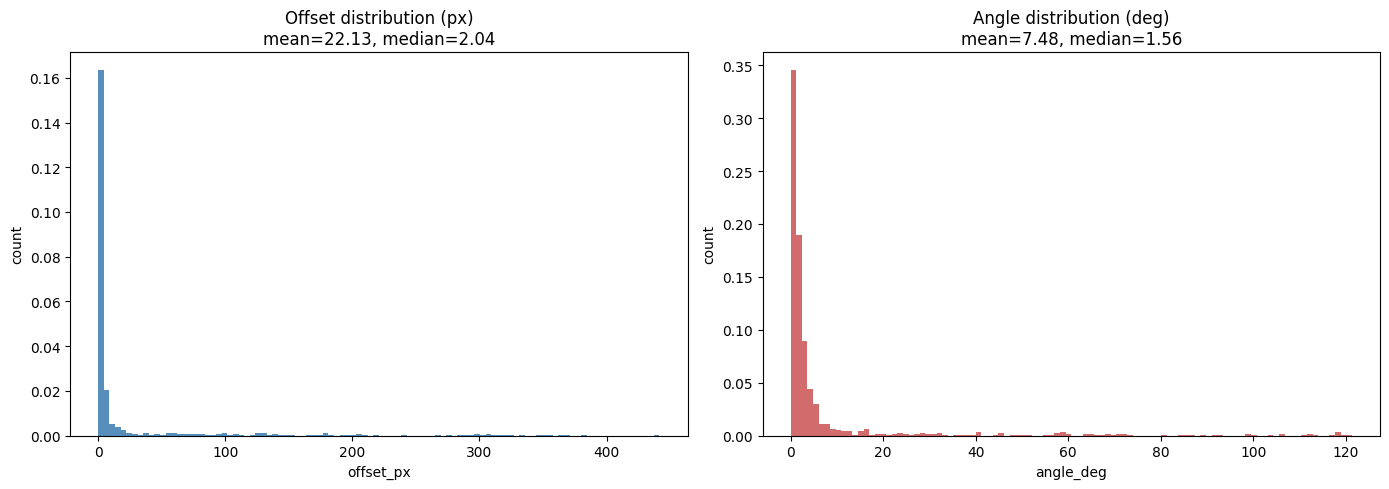

In [16]:
# Histograms: offset distribution + angle distribution
import numpy as np
import matplotlib.pyplot as plt

# Si ta cellule précédente a tourné, angles/offsets sont déjà définis
# sinon, on essaye de les reconstruire depuis rows.
if "angles0" not in globals() or "offsets0" not in globals():
    if "rows" in globals() and len(rows) > 0:
        angles0 = np.array([r["angle_deg"] for r in rows], dtype=np.float64)
        offsets0 = np.array([r["offset_px"] for r in rows], dtype=np.float64)
    else:
        raise NameError("Variables `angles`/`offsets` (ou `rows`) introuvables. Lance d'abord la cellule d'évaluation.")


angles = np.array([r["angle_deg"] for r in rows], dtype=np.float64)
offsets = np.array([r["offset_px"] for r in rows], dtype=np.float64)
# Nettoyage NaN/inf
angles_f = angles0[np.isfinite(angles0)]
offsets_f = offsets0[np.isfinite(offsets0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Offset histogram
axes[0].hist(offsets_f, bins=100, color="steelblue", alpha=0.9, density=True)
axes[0].set_title(f"Offset distribution (px)\nmean={np.nanmean(offsets_f):.2f}, median={np.nanmedian(offsets_f):.2f}")
axes[0].set_xlabel("offset_px")
axes[0].set_ylabel("count")

# Angle histogram
axes[1].hist(angles_f, bins=100, color="indianred", alpha=0.9, density=True)
axes[1].set_title(f"Angle distribution (deg)\nmean={np.nanmean(angles_f):.2f}, median={np.nanmedian(angles_f):.2f}")
axes[1].set_xlabel("angle_deg")
axes[1].set_ylabel("count")





plt.tight_layout()
plt.show()

In [34]:
!ffmpeg -ss 00:01:10 -i runs/segment/one_stage/HPA_LA_720p_10hz_runway_centerline_scanline.mp4 -t 00:02:00 runs/segment/one_stage/HPA_LA_720p_10hz_runway_centerline_scanline-cut.mp4

ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'runs/segment/one_stage/HPA_LA_720p_10hz_runway_centerline_scanline.mp4':
  Metadata:
    major_brand     : isom
    minor_version   : 512
    compatible_brands: isomiso

In [33]:
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ["PATH"]
!ffmpeg -version

ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
built with Apple clang version 17.0.0 (clang-1700.6.4.2)
configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
libavutil      60. 26.100 / 60. 26.100
libavcodec     62. 28.100 / 62. 28.100
libavformat    62. 12.100 / 62. 12.100
libavdevice    62.  3.100 / 62.  3.100
libavfilter    11. 14.100 / 11. 14.100
libswscale      9.  5.100 /  9.  5.100
libswresample   6.  3.100 /  6.  3.100

Exiting with exit code 0
